In [1]:
import os
import glob
import gc
import random
import re

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
PATH = '/mnt/sdb/scz_meta_analysis_processed/anndata_objs/'

In [3]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')
adata_hvg = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_hvg.h5ad', backed='r')

adata.obsm = adata_hvg.obsm.copy()
adata.obsp = adata_hvg.obsp.copy()
adata.uns = adata_hvg.uns.copy()

del adata_hvg
gc.collect()

35935

In [4]:
## First Round Clustering ##

if not isinstance(adata, UnimodalData):
    adata = UnimodalData(adata)

# already calculatd neighbors off scVI space
pg.neighbors(adata, rep='scVI', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(adata, rep='scVI', resolution=0.1, class_label='class')
adata.obs['class'] = adata.obs['class'].astype('str').astype("category")

# create scanpy anndata object
adata = adata.to_anndata()

2026-03-15 19:55:40,373 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 189.17s.
2026-03-15 19:56:05,727 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 25.35s.
2026-03-15 19:56:37,043 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 31.31s.
2026-03-15 20:02:47,361 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 2 clusters.
2026-03-15 20:02:48,125 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 402.40s.


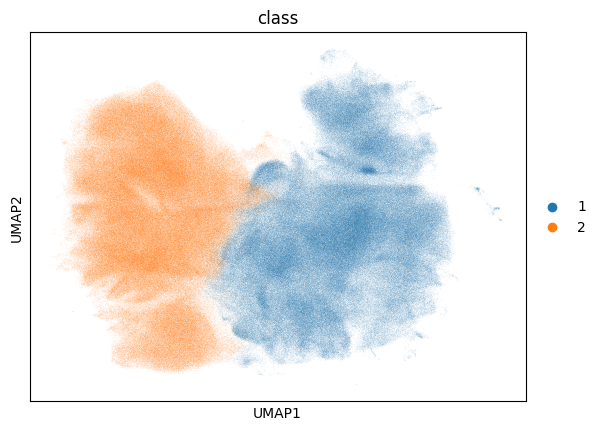

In [5]:
sc.pl.umap(adata, color='class')

In [6]:
def subcluster_scvi_per_cluster(adata, class_label="class", new_class_label="subclass",
                                resolution=0.2, n_hvg=3000, max_epochs=20, min_cells_per_cluster=50, 
                                min_donors_per_cluster=3, min_cells_per_batch=10, umap=False):
    
    """
    Subcluster SCVI latent space per cluster, robust to small clusters and tiny batches.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object.
    class_label : str
        Column in adata.obs indicating parent clusters.
    new_class_label : str
        Column name for the resulting subclusters.
    resolution : float
        Leiden clustering resolution.
    n_hvg : int
        Number of highly variable genes to select (clamped to available genes).
    max_epochs : int
        Maximum SCVI training epochs.
    min_cells_per_cluster : int
        Skip clusters smaller than this number of cells.
    min_donors_per_cluster : int
        Skip clusters with fewer donors than this.
    min_cells_per_batch : int
        Minimum cells per batch to include batch_key in HVG selection.
    """

    adata.obs[new_class_label] = pd.Series(index=adata.obs_names, dtype="object")

    for parent in sorted(adata.obs[class_label].unique()):

        print(f"\nSubclustering parent: {parent}")
        mask = adata.obs[class_label] == parent
        adata_cluster = adata[mask].copy()
        n_cells = adata_cluster.n_obs
        n_donors = adata_cluster.obs["Donor"].nunique()

        # Skip clusters that are too small or only have 1 donor
        if n_cells < min_cells_per_cluster or n_donors < min_donors_per_cluster:
            print(f"Skipping cluster {parent}: {n_cells} cells, {n_donors} donor(s)")
            adata.obs.loc[mask, new_class_label] = str(parent) + "_0"
            continue

        print("Cells:", n_cells)
        print("Donors:", n_donors)
        print("Manuscripts:", adata_cluster.obs["Manuscript"].nunique())

        # --- Determine which manuscripts meet the min_cells_per_batch threshold ---
        batch_counts = adata_cluster.obs["Manuscript"].value_counts()
        valid_batches = batch_counts[batch_counts >= min_cells_per_batch].index
        adata_cluster_valid = adata_cluster[adata_cluster.obs["Manuscript"].isin(valid_batches)].copy()

        if valid_batches.shape[0] != batch_counts.shape[0]:
            print("Insufficient Cells Coming From Some Manuscripts, Removing Them For HVG Calculation")
            print(f"Batch Counts are {batch_counts.shape[0]} and Valid Batches are {valid_batches.shape[0]}")


        # ---- Restrict HVG Calculation to the Robust Protein Coding Autosome --- 
        adata_cluster_valid = adata_cluster_valid[:,adata_cluster_valid.var.robust_protein_coding_autosome].copy()
        
        # --- HVG selection only on the valid manuscripts ---
        sc.pp.highly_variable_genes(adata_cluster_valid, layer="log1p_norm", n_top_genes=n_hvg, batch_key="Manuscript", subset=True)

        # --- Get the selected HVGs ---
        hvg_genes = adata_cluster_valid.var[adata_cluster_valid.var['highly_variable']].index

        # --- Now, apply the HVG selection to the full cluster (adata_cluster) ---
        adata_cluster = adata_cluster[:, hvg_genes].copy()

        # --- SCVI setup & training ---
        scvi.model.SCVI.setup_anndata(
            adata_cluster,
            layer="raw_counts",
            categorical_covariate_keys=["Donor", "Manuscript", "Sex"],
            continuous_covariate_keys=["n_counts", "percent_mito"])

        model = scvi.model.SCVI(adata_cluster, n_hidden=512, n_latent=20, n_layers=2)

        model.train(max_epochs=max_epochs, early_stopping=True, batch_size=1024)

        # --- Get latent representation ---
        adata_cluster.obsm["scVI"] = model.get_latent_representation()

        # --- Leiden clustering ---
        adata_cluster = UnimodalData(adata_cluster)
        pg.neighbors(adata_cluster, rep='scVI', use_cache=False, dist='l2', K=100, n_comps=30)
        pg.leiden(adata_cluster, rep="scVI", resolution=resolution, class_label=new_class_label)

        # --- Assign hierarchical labels ---
        hierarchical_labels = str(parent) + "_" + adata_cluster.obs[new_class_label].astype(str)
        adata.obs.loc[mask, new_class_label] = hierarchical_labels.values

        if umap:
            assert adata.obs[class_label].nunique() == 1, \
                "UMAP transfer only works when adata contains a single parent cluster"
            pg.umap(adata_cluster, rep='scVI', n_neighbors=15, rep_ncomps=30)
            adata.obsm["X_umap"] = adata_cluster.obsm["X_umap"]

        # --- Clean up memory ---
        del model
        del adata_cluster
        del adata_cluster_valid
        gc.collect()

    return adata

In [7]:
## Cluster ##

# Generate Subclasses #
adata = subcluster_scvi_per_cluster(adata,  class_label="class", new_class_label="subclass", n_hvg=2000, resolution=0.2, max_epochs=20)

# Generate Subtypes #
adata = subcluster_scvi_per_cluster(adata, class_label='subclass', new_class_label='subtype', n_hvg=1000, resolution=0.3, max_epochs=20)


Subclustering parent: 1
Cells: 823644
Donors: 40
Manuscripts: 9


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


2026-03-15 20:23:35,475 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 87.43s.
2026-03-15 20:23:48,724 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 13.25s.
2026-03-15 20:24:04,353 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 15.63s.
2026-03-15 20:28:48,290 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 5 clusters.
2026-03-15 20:28:48,685 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 299.96s.

Subclustering parent: 2
Cells: 750521
Donors: 40
Manuscripts: 9


...

2026-03-15 21:32:29,694 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 10.36s.
2026-03-15 21:32:31,596 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 1.90s.
2026-03-15 21:32:33,835 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 2.24s.
2026-03-15 21:32:57,334 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 3 clusters.
2026-03-15 21:32:57,406 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 25.81s.

Subclustering parent: 2_4
Cells: 117995
Donors: 38
Manuscripts: 9
Insufficient Cells Coming From Some Manuscripts, Removing Them For HVG Calculation
Batch Counts are 9 and Valid Batches are 8


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 20 in adata.obs['Donor'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


2026-03-15 21:35:55,221 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 9.90s.
2026-03-15 21:36:04,841 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 9.62s.
2026-03-15 21:36:09,726 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 4.88s.
2026-03-15 21:36:33,742 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 4 clusters.
2026-03-15 21:36:33,821 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 28.98s.


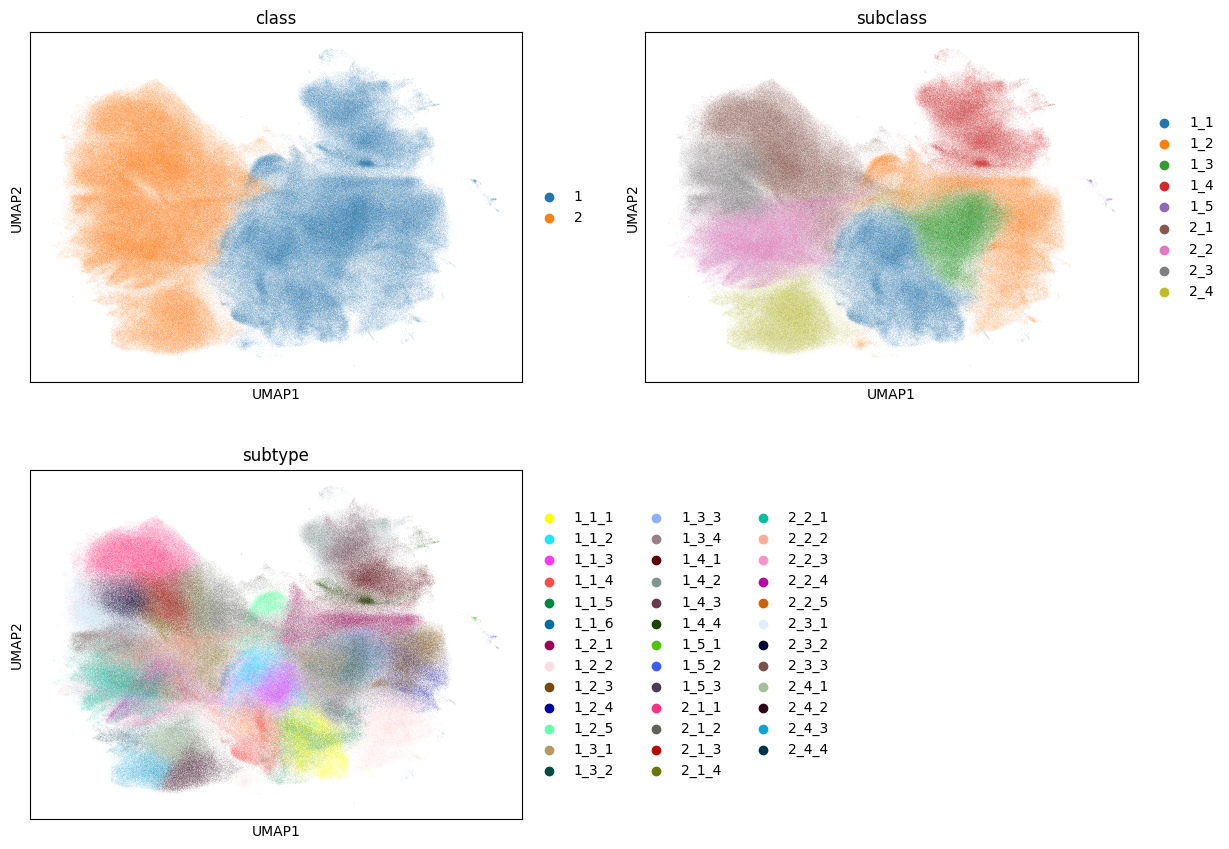

In [8]:
sc.pl.umap(adata, color=['class', 'subclass', 'subtype'], ncols=2)

In [9]:
## Calculate DGEs ##

pg.de_analysis(adata, 'class', de_key='class_key')

for adata_class in adata.obs['class'].unique():
    subclass_labels = [x for x in adata.obs['subclass'].unique() if str(x).startswith(f"{adata_class}_")]
    pg.de_analysis(adata, 'subclass', de_key=f'class_{adata_class}_subclasses_key', subset=subclass_labels)

for adata_subclass in adata.obs['subclass'].unique():
    subtype_labels = [x for x in adata.obs['subtype'].unique() if str(x).startswith(f"{adata_subclass}_")]
    pg.de_analysis(adata, 'subtype', de_key=f'subclass_{adata_subclass}_subtypes_key', subset=subtype_labels)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/diff_expr.py:449: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(cluster_labels):


2026-03-15 21:37:04,654 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 16.6664s.
2026-03-15 21:37:51,579 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 46.9252s.
2026-03-15 21:37:54,309 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 2.7296s.
2026-03-15 21:37:54,353 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-03-15 21:37:54,354 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 66.38s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/diff_expr.py:449: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(cluster_labels):


2026-03-15 21:38:05,027 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 7.8463s.
2026-03-15 21:38:25,056 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 20.0283s.
2026-03-15 21:38:26,368 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 1.3125s.
2026-03-15 21:38:26,395 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-03-15 21:38:26,408 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 32.05s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/diff_expr.py:449: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(cluster_labels):


...

2026-03-15 21:39:58,831 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 1.0871s.
2026-03-15 21:40:01,534 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 2.7027s.
2026-03-15 21:40:01,727 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 0.1931s.
2026-03-15 21:40:01,739 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-03-15 21:40:01,741 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 4.49s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/diff_expr.py:449: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(cluster_labels):


2026-03-15 21:40:03,501 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 1.2540s.
2026-03-15 21:40:06,578 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 3.0767s.
2026-03-15 21:40:06,784 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 0.2058s.
2026-03-15 21:40:06,796 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-03-15 21:40:06,799 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 5.05s.
2026-03-15 21:40:06,857 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 0.0025s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/diff_expr.py:449: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(cluster_labels):


2026-03-15 21:40:07,125 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 0.2681s.
2026-03-15 21:40:07,131 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 0.0064s.
2026-03-15 21:40:07,140 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-03-15 21:40:07,140 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 0.34s.


In [10]:
## Build DGE Lists ##

# Classes #
class_dge = pd.concat([pg.markers(adata, de_key='class_key')[i]['up'] for i in pg.markers(adata, de_key='class_key').keys()], 
                       keys=pg.markers(adata, de_key='class_key').keys(),
                       names=['cluster'],
                       axis=0).reset_index()

# --- Subclasses ---
subclass_dfs = []
for cls in adata.obs['class'].unique():
    markers_dict = pg.markers(adata, de_key=f'class_{cls}_subclasses_key')
    for subcls, df in markers_dict.items():
        df_up = df['up'].copy()
        df_up['parent_class'] = cls
        df_up['subclass'] = subcls
        subclass_dfs.append(df_up)

# Concatenate while keeping gene names as the index
subclass_dge = pd.concat(subclass_dfs, ignore_index=False)

# --- Subtypes ---
subtype_dfs = []
for subcls in adata.obs['subclass'].unique():
    markers_dict = pg.markers(adata, de_key=f'subclass_{subcls}_subtypes_key')
    for stype, df in markers_dict.items():
        df_up = df['up'].copy()
        df_up['parent_subclass'] = subcls
        df_up['subtype'] = stype
        subtype_dfs.append(df_up)

# Concatenate while keeping gene names as the index
subtype_dge = pd.concat(subtype_dfs, ignore_index=False)

In [11]:
class_dge.to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/scDGE_total_class.csv')

In [12]:
subclass_dge.to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/scDGE_class_subclass.csv')

In [13]:
subtype_dge.to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/scDGE_subclass_subtype.csv')

In [14]:
adata.obs[['class', 'subclass', 'subtype']].to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/iterative_clustering_table.csv')

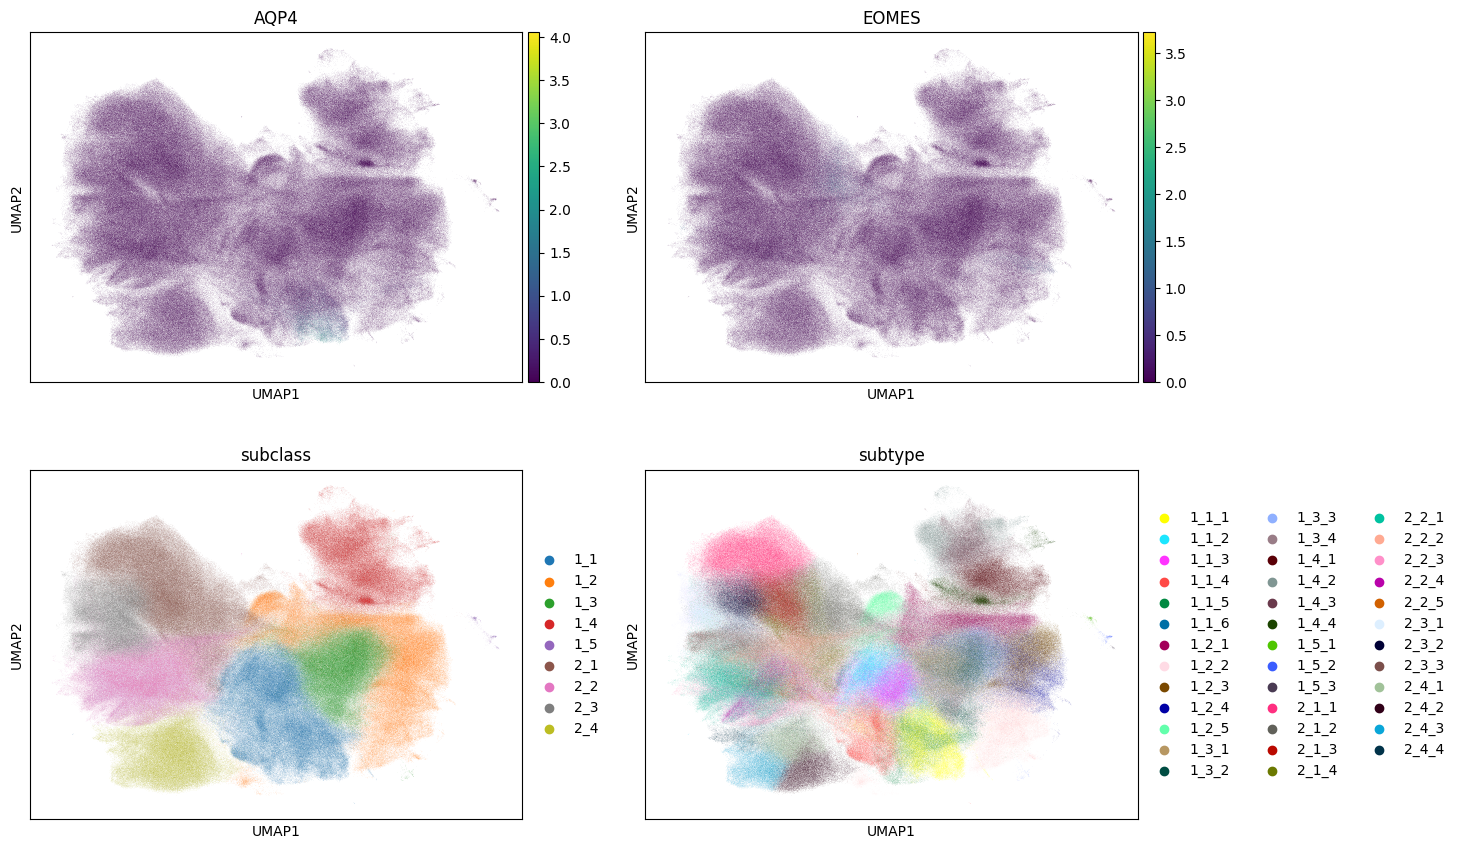

In [15]:
sc.pl.umap(adata, color=['AQP4', 'EOMES', 'subclass', 'subtype'], ncols=2)